# Hotel Booking Demand Analysis & Machine Learning Prediction
**Author**: Data Science & Hospitality Analytics Suite  
**Dataset**: 119,390 records across City Hotel and Resort Hotel (2015 - 2017)  
**Objectives**:
1. Exploratory Data Analysis (EDA) uncovering key cancellation drivers, seasonality, and pricing patterns.
2. Machine Learning pipeline to predict booking cancellations (`is_canceled`) with zero data leakage.
3. Operational recommendations and risk mitigation strategies.

## 1. Environment & Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load raw dataset
df = pd.read_csv('hotel_bookings.csv')
print(f"Raw dataset shape: {df.shape}")
df.head()

Raw dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Data Cleaning & Integrity Safeguards
We identify and resolve:
- Missing values in `children`, `country`, `agent`, and `company`.
- Anomaly entries where total guests (`adults + children + babies`) equals 0.
- ADR (Average Daily Rate) outliers (negative values and extreme entries > $1,000).

In [3]:
from src.data_pipeline import clean_data, engineer_features

print(f"Null values before cleaning:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

df_clean = clean_data(df)
df_featured = engineer_features(df_clean)
print(f"\nCleaned & Featured dataset shape: {df_featured.shape}")
print(f"Overall Cancellation Rate: {df_featured['is_canceled'].mean():.2%}")

Null values before cleaning:
children         4
country        488
agent        16340
company     112593
dtype: int64

Cleaned & Featured dataset shape: (119208, 40)
Overall Cancellation Rate: 37.08%


## 3. Exploratory Data Analysis: Key Insights
### 3.1 Hotel Type Cancellation Dynamics

,total_bookings,cancellations,cancellation_rate,avg_adr,avg_lead_time
hotel,,,,,
City Hotel,79162,33078,41.79,105.44,109.9
Resort Hotel,40046,11120,27.77,94.99,92.7


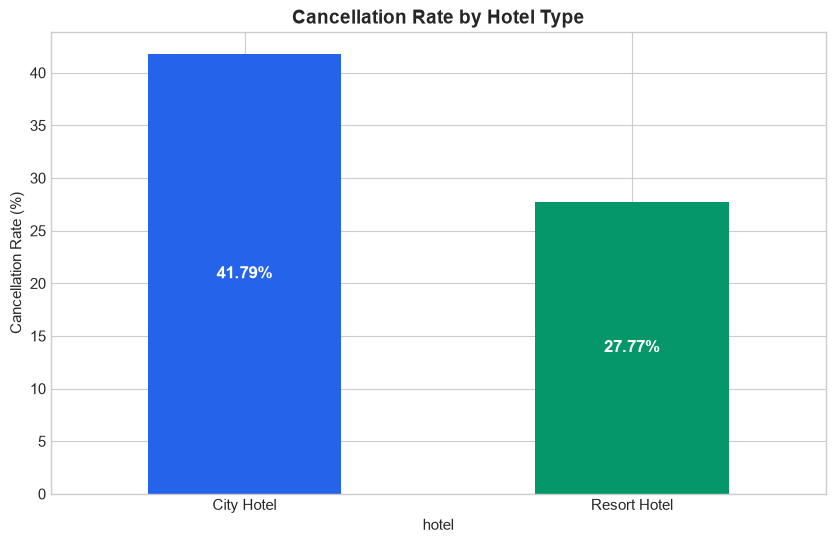

In [4]:
hotel_summary = df_featured.groupby('hotel').agg(
    total_bookings=('is_canceled', 'count'),
    cancellations=('is_canceled', 'sum'),
    cancellation_rate=('is_canceled', lambda x: round(x.mean() * 100, 2)),
    avg_adr=('adr', lambda x: round(x.mean(), 2)),
    avg_lead_time=('lead_time', lambda x: round(x.mean(), 1))
)
display(hotel_summary)

# Visualization
ax = hotel_summary['cancellation_rate'].plot(kind='bar', color=['#2563eb', '#059669'], rot=0)
plt.title('Cancellation Rate by Hotel Type', fontsize=14, fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
for p in ax.patches:
    ax.annotate(f"{p.get_height()}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)
plt.show()

### 3.2 Lead Time Horizon vs. Cancellation Probability

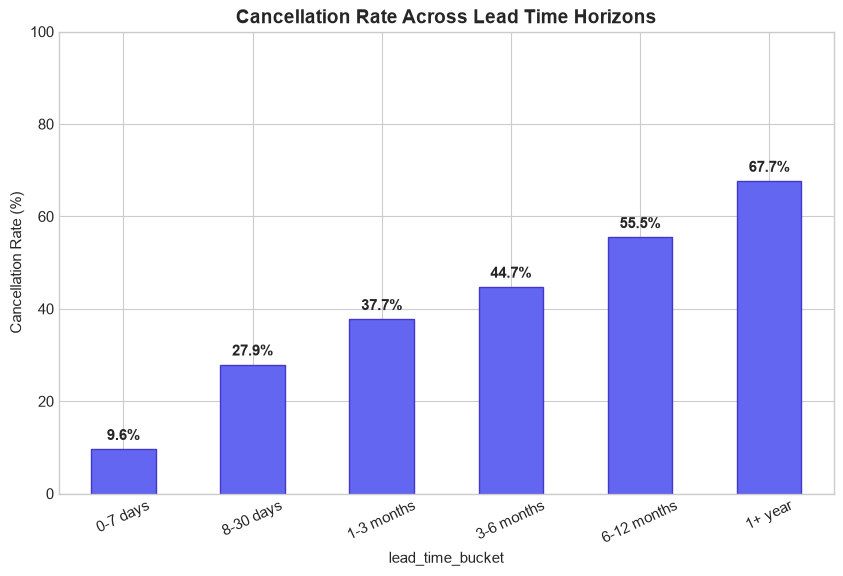

In [5]:
bins = [0, 7, 30, 90, 180, 365, 800]
labels = ['0-7 days', '8-30 days', '1-3 months', '3-6 months', '6-12 months', '1+ year']
df_featured['lead_time_bucket'] = pd.cut(df_featured['lead_time'], bins=bins, labels=labels, include_lowest=True)

lt_rate = df_featured.groupby('lead_time_bucket', observed=False)['is_canceled'].mean() * 100
ax = lt_rate.plot(kind='bar', color='#6366f1', edgecolor='#4338ca', rot=25)
plt.title('Cancellation Rate Across Lead Time Horizons', fontsize=14, fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 100)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 2),
                ha='center', fontweight='bold')
plt.show()

### 3.3 The Deposit Paradox & Market Segments

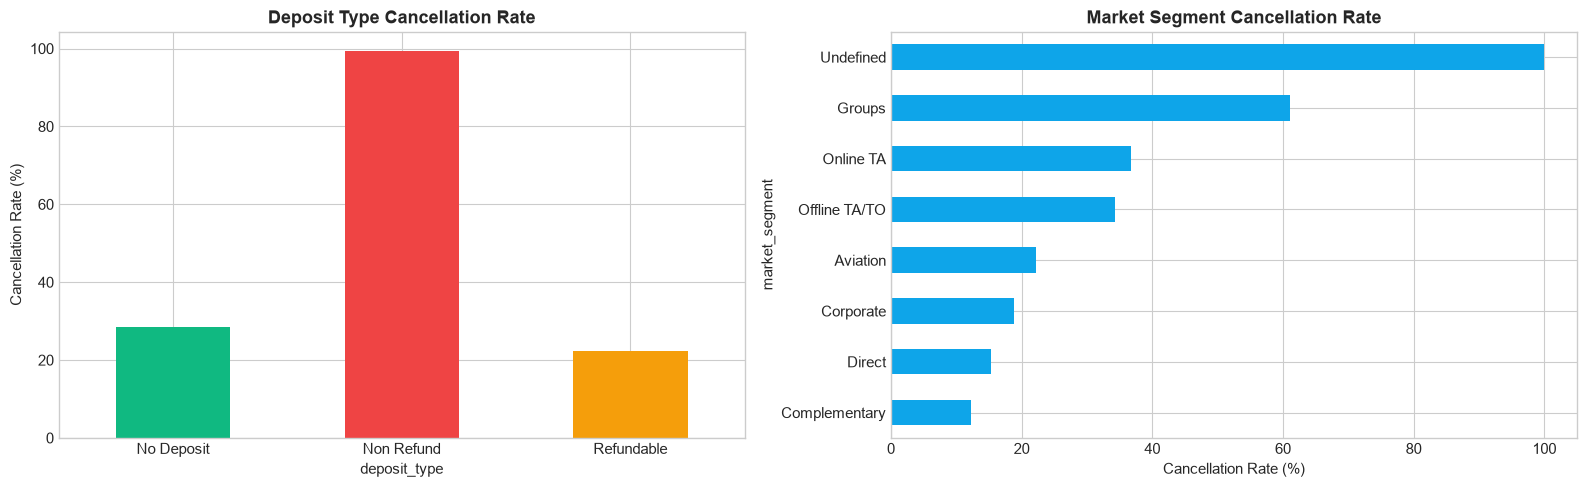

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Deposit Type
dep_rate = df_featured.groupby('deposit_type')['is_canceled'].mean() * 100
dep_rate.plot(kind='bar', ax=axes[0], color=['#10b981', '#ef4444', '#f59e0b'], rot=0)
axes[0].set_title('Deposit Type Cancellation Rate', fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (%)')

# Market Segment
seg_rate = df_featured.groupby('market_segment')['is_canceled'].mean().sort_values() * 100
seg_rate.plot(kind='barh', ax=axes[1], color='#0ea5e9')
axes[1].set_title('Market Segment Cancellation Rate', fontweight='bold')
axes[1].set_xlabel('Cancellation Rate (%)')

plt.tight_layout()
plt.show()

## 4. Machine Learning Model Training & Evaluation
- Target: `is_canceled`
- Zero Data Leakage: Strictly dropped `reservation_status` and `reservation_status_date`.

In [7]:
from src.model_trainer import train_and_evaluate_all

best_pipeline, metadata = train_and_evaluate_all('hotel_bookings.csv', 'models')

# Display Benchmark Comparison
benchmark_df = pd.DataFrame(metadata['models_benchmark']).T[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'train_time_seconds']]
benchmark_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'Train Time (s)']
display(benchmark_df)

Preparing dataset for ML modeling...
Dataset shape: (119208, 33), Target cancellation rate: 37.08%

--- Training Logistic Regression ---
Training completed in 3.15s
Accuracy: 0.8108 | ROC-AUC: 0.8695 | F1: 0.7125

--- Training Random Forest ---
Training completed in 8.54s
Accuracy: 0.8339 | ROC-AUC: 0.9157 | F1: 0.7436

--- Training Gradient Boosting (Hist) ---
Training completed in 9.6s
Accuracy: 0.8410 | ROC-AUC: 0.9143 | F1: 0.7645

>> Best performing model: Random Forest (ROC-AUC: 0.9157)
Saved model pipeline to models\best_cancellation_model.joblib
Saved model metadata and benchmark to models\model_metrics.json


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s)
Logistic Regression,0.8108,0.8162,0.6322,0.7125,0.8695,3.15
Random Forest,0.8339,0.869,0.6499,0.7436,0.9157,8.54
Gradient Boosting (Hist),0.841,0.848,0.6959,0.7645,0.9143,9.6


## 5. Live Simulation & Operational Prediction Engine

In [8]:
from src.predictor import BookingCancellationPredictor

predictor = BookingCancellationPredictor('models/best_cancellation_model.joblib')

# Test booking simulation
sample_booking = {
    'hotel': 'City Hotel',
    'lead_time': 120,
    'arrival_date_month': 'August',
    'stays_in_weekend_nights': 1,
    'stays_in_week_nights': 3,
    'adults': 2,
    'market_segment': 'Online TA',
    'deposit_type': 'No Deposit',
    'adr': 115.0,
    'total_of_special_requests': 0
}

result = predictor.predict_booking(sample_booking)
print(f"Cancellation Probability: {result['cancellation_probability']}%")
print(f"Risk Tier: {result['risk_tier']}")
print(f"Key Drivers: {result['key_drivers']}")
print(f"Recommended Actions: {result['recommended_actions']}")

Cancellation Probability: 53.2%
Risk Tier: Moderate Risk
Key Drivers: ['Zero special requests submitted, reflecting low initial engagement.']
Recommended Actions: ['Offer complimentary upgrade options or personalized amenities to increase engagement.', 'City Hotel bookings benefit from active overbooking buffer rules (5-8% target).']
